In [12]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib as mpl

# --- 1. Load your CSV ---
# df = pd.read_csv("county_drug_death.csv")
df = pd.read_csv("pop_normalized_county_drug_death.csv")


# --- 2. Download US counties shapefile (Census TIGER) ---
url = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
gdf = gpd.read_file(url)

In [13]:
# --- 3. Filter to Ohio (state FIPS = 39) ---
gdf = gdf[gdf["STATEFP"] == "39"]

# --- 4. Clean names for matching ---
df['Unnamed: 0'] = df['Unnamed: 0'].str.lower().str.replace(" county", "", regex=False)
df.rename(columns={'Unnamed: 0': 'county'}, inplace=True)

def clean_county(s):
    return (
        s.str.lower()
         .str.replace(" county", "", regex=False)
         .str.replace(" ", "", regex=False)   # 👈 removes ALL spaces
    )

df["county"] = clean_county(df["county"])
gdf["NAME"] = clean_county(gdf["NAME"])


# --- 5.      Merge ---
merged = gdf.merge(df, left_on="NAME", right_on="county")

month_cols = [col for col in merged.columns if (col.startswith("20"))]

month_cols = sorted(month_cols, key=lambda x: (
    int(x.split("_")[0]),
    int(x.split("_")[1])
))

# --- 2. Convert to cumulative ---
merged[month_cols] = merged[month_cols].cumsum(axis=1)

# Make a GIF with Matplotlib

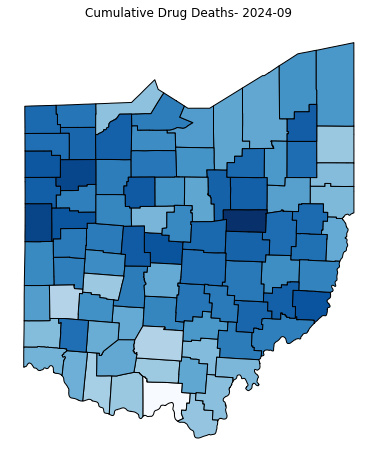

In [14]:

# --- 3. Set up figure ---
fig, ax = plt.subplots(figsize=(8, 8))

# --- 4. Animation function ---
def update(month):
    ax.clear()
    
    # 👇 compute per-frame scale
    vmin = merged[month].min()
    vmax = merged[month].max()

    merged.plot(
        column=month,
        ax=ax,
        cmap="Blues_r",
        edgecolor="black",
        vmin=vmin,
        vmax=vmax,
        legend=False  # 🚨 prevent new colorbars
    )

    year, m = month.split("_")
    ax.set_title(f"Cumulative Drug Deaths- {year}-{int(m):02d}")
    ax.axis("off")

# --- 5. Animate ---
ani = FuncAnimation(fig, update, frames=month_cols, repeat=False)

ani.save("ohio_normalized_cumulative_deaths.gif", fps=3)

plt.show()

# Interactive Slider with Plotly

In [ ]:
import json
import plotly.express as px

# Plotly works best with a non-geometry dataframe for the animation frame data
plot_df = merged.drop(columns="geometry").melt(
    id_vars=["GEOID", "NAME"],
    value_vars=month_cols,
    var_name="month",
    value_name="deaths"
)

# Make sure GEOID is treated as text
plot_df["GEOID"] = plot_df["GEOID"].astype(str)

# GeoJSON from the merged GeoDataFrame
geojson = json.loads(merged.to_json())

fig = px.choropleth(
    plot_df,
    geojson=geojson,
    locations="GEOID",
    featureidkey="properties.GEOID",
    color="deaths",
    animation_frame="month",
    animation_group="GEOID",
    color_continuous_scale="Reds_r",
    range_color=(plot_df["deaths"].min(), plot_df["deaths"].max()),
    scope="usa",
    labels={"deaths": "Cumulative deaths", "month": "Month"},
    hover_name="NAME",
    hover_data={"GEOID": False, "month": True, "deaths": True},
)

fig.update_geos(fitbounds="locations", vxisible=False)
fig.update_layout(
    title="Ohio Cumulative Drug Deaths Over Time",
    coloraxis_colorbar_title="Deaths",
)

fig.show()